# Analyze distinct properties in the 15,000 politician sample

This notebook analyzes the distinct properties found in the statement-level data of the 15,000 sampled politicians.

Input file: `15000politician_statements.csv.gz`  
Output files:  
`15000politician_distinct_property_summary.xlsx`  
`15000politician_property_discovery_curve.png`

The analysis first keeps one row for each unique entity-property pair. It then calculates the cumulative set of distinct property IDs across the sampled entities. A property that appears in multiple entities is counted only once in the cumulative distinct-property total.

The summary table records the cumulative number of distinct properties after each group of 500 entities. The property discovery curve visualizes how the number of distinct properties increases as more sampled entities are included.

/var/folders/2s/qtvrpw5114sb5tz43vfxbf3r0000gn/T/ipykernel_16010/1557720917.py:4: DtypeWarning: Columns (32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("15000politician_statements.csv.gz", compression="gzip")


Number of entities in the statement file: 15000
Total number of distinct properties: 1759


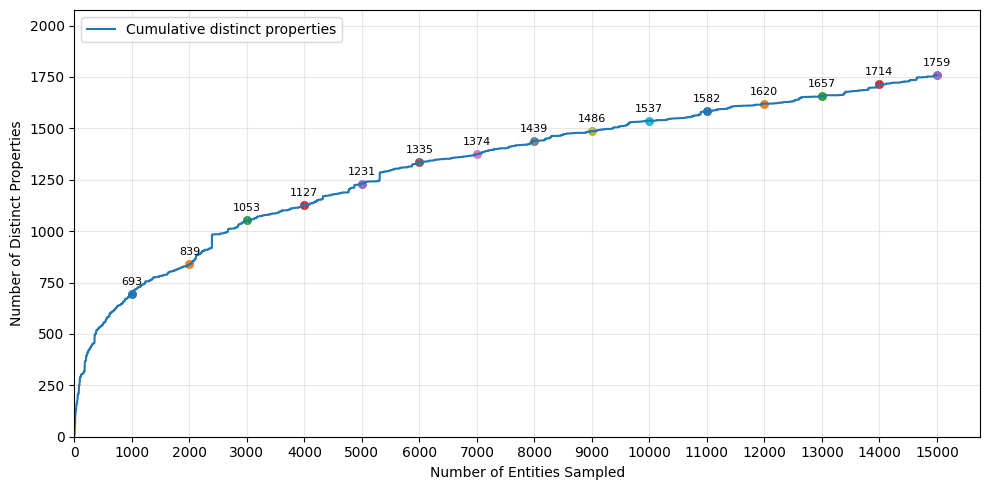

Property discovery curve saved to New15000politician_property_discovery_curve.png
Summary table saved to New15000politician_distinct_property_summary.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("15000politician_statements.csv.gz", compression="gzip")
df = df[["QID", "Property_ID"]].dropna()
df = df.drop_duplicates(subset=["QID", "Property_ID"])

qid_order = df["QID"].drop_duplicates().tolist()

entity_properties = df.groupby("QID")["Property_ID"].apply(set).to_dict()

N = len(qid_order)

print(f"Number of entities in the statement file: {N}")


# Calculate cumulative property discovery
cumulative_properties = set()
cumulative_counts = []

for qid in qid_order:
    cumulative_properties.update(entity_properties.get(qid, set()))
    cumulative_counts.append(len(cumulative_properties))

total_properties = cumulative_counts[-1]

print(f"Total number of distinct properties: {total_properties}")



window = 500
previous_count = 0
summary_rows = []

for n in range(window, N + 1, window):
    current_count = cumulative_counts[n - 1]
    new_count = current_count - previous_count
    coverage = current_count / total_properties * 100

    summary_rows.append({
        "Number_of_Entities": n,
        "Cumulative_Properties": current_count,
        "Coverage_Percentage": coverage,
        "New_Properties": new_count
    })

    previous_count = current_count

# If the number of entities is not exactly divisible by 500
if N % window != 0:
    current_count = cumulative_counts[-1]
    new_count = current_count - previous_count
    coverage = current_count / total_properties * 100

    summary_rows.append({
        "Number_of_Entities": N,
        "Cumulative_Properties": current_count,
        "Coverage_Percentage": coverage,
        "New_Properties": new_count
    })


summary_df = pd.DataFrame(summary_rows)
summary_file = "15000politician_distinct_property_summary.xlsx"
summary_df.to_excel(summary_file, index=False)


#increment_x = []
#increment_y = []

#previous_count = 0

#for n in range(window, N + 1, window):
#    current_count = cumulative_counts[n - 1]
#    increment_x.append(n)
#    increment_y.append(current_count - previous_count)
#    previous_count = current_count

#if N % window != 0:
#    current_count = cumulative_counts[-1]
#    increment_x.append(N)
#    increment_y.append(current_count - previous_count)


# cumulative property discovery curve
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, N + 1),
    cumulative_counts,
    linewidth=1.5,
    label="Cumulative distinct properties"
)

#plt.axhline(
#    y=total_properties,
#    linestyle="--",
#    linewidth=1,
#    alpha=0.6,
#    label=f"Total: {total_properties} properties"
#)

milestones = [1000, 2000, 3000, 4000, 5000,6000, 7000, 8000, 9000, 10000,11000, 12000, 13000, 14000, N]

for n in milestones:
    if n <= N:
        value = cumulative_counts[n - 1]
        plt.scatter(n, value, s=30)
        plt.annotate(
            str(value),
            xy=(n, value),
            xytext=(n, value + total_properties * 0.025),
            fontsize=8,
            ha="center"
        )

plt.xlabel("Number of Entities Sampled")
plt.ylabel("Number of Distinct Properties")
plt.title(f"")

plt.legend(
    loc="upper left",
    frameon=True
)
plt.grid(True, alpha=0.3)
plt.xlim(0, N * 1.05)
plt.ylim(0, total_properties * 1.18)
plt.xticks(range(0, N + 1000, 1000))

plt.tight_layout()

curve_file = "15000politician_property_discovery_curve.png"
plt.savefig(curve_file, dpi=150, bbox_inches="tight")
plt.show()

print(f"Property discovery curve saved to {curve_file}")

#new property count per 500 entities
#plt.figure(figsize=(10, 5))

#plt.bar(increment_x, increment_y, width=window * 0.8, align="center")

#for x_value, y_value in zip(increment_x, increment_y):
#    plt.text(
#        x_value,
#        y_value + 1,
#        str(y_value),
#        ha="center",
#        va="bottom",
#        fontsize=7
#    )

#plt.xlabel("Number of Entities Sampled")
#plt.ylabel("Number of New Properties")
#plt.title(f"New Property Discovery Count\n(Politician domain, n={N})")
#plt.grid(True, alpha=0.3, axis="y")
#plt.xticks(range(0, N + 1000, 1000))

#plt.tight_layout()

#increment_file = "15000politician_new_property_count.png"
#plt.savefig(increment_file, dpi=150, bbox_inches="tight")
#plt.show()

#print(f"New property count figure saved to {increment_file}")

print(f"Summary table saved to {summary_file}")